In [1]:
import pandas as pd
import numpy as np

In [38]:
df = pd.read_csv(r"C:\Users\ryana\Downloads\DataSet\retail_store_inventory.csv")
pd.set_option('display.max_columns', None)

In [3]:
df.sample(2)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
32629,2022-11-23,S002,P0010,Toys,West,370,228,123,226.26,83.57,20,Cloudy,0,80.74,Winter
26741,2022-09-25,S003,P0002,Electronics,West,322,76,143,78.45,29.22,5,Sunny,1,28.01,Summer


In [32]:
df['Seasonality'].unique()

array(['Autumn', 'Summer', 'Winter', 'Spring'], dtype=object)

In [5]:
df.shape

(73100, 15)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [ ]:
df['Date'] = pd.datetime(df['Date'])

In [34]:
cols = ['Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality']

for cols_type in cols:
    df[cols_type] = df[cols_type].astype('category')
    print(f"{cols_type} completely changed to category type")

Store ID completely changed to category type
Product ID completely changed to category type
Category completely changed to category type
Region completely changed to category type
Weather Condition completely changed to category type
Seasonality completely changed to category type


In [7]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

### Identify Outlier

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

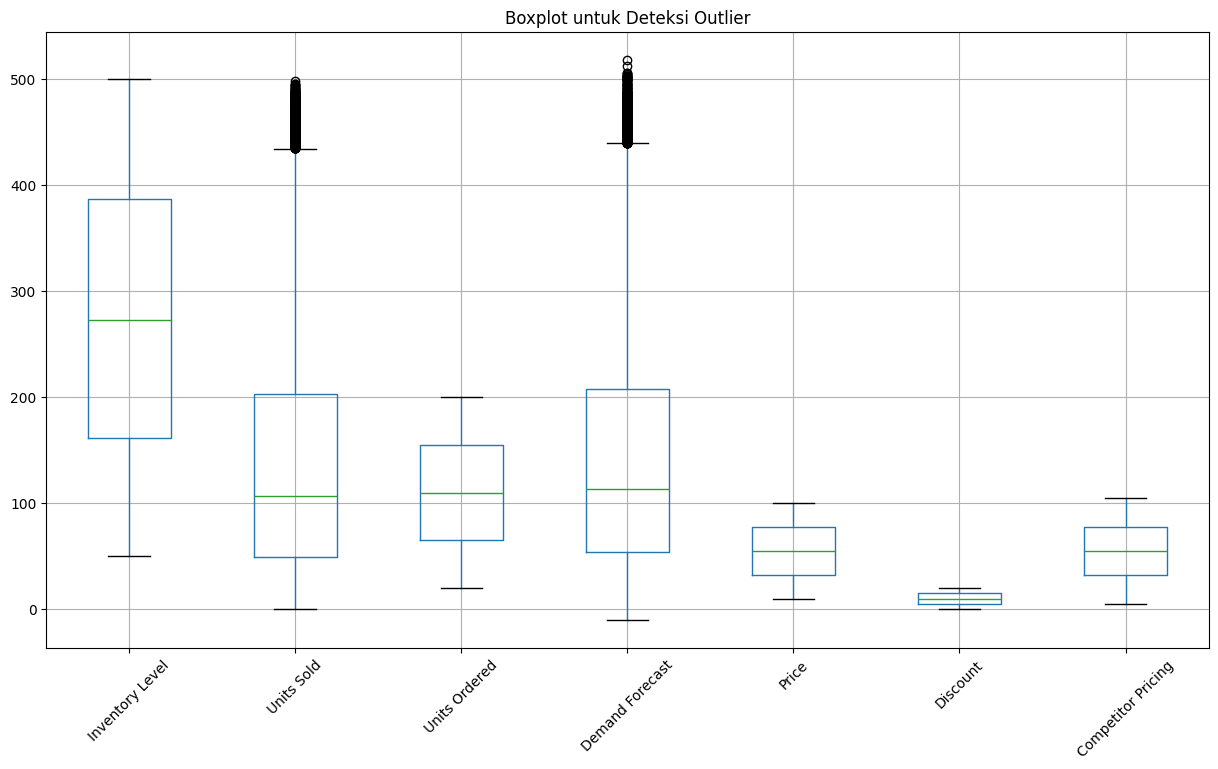

In [10]:
# Cek tipe data numerik
numeric_cols = ['Inventory Level', 'Units Sold', 'Units Ordered', 
                'Demand Forecast', 'Price', 'Discount', 'Competitor Pricing']

# Boxplot untuk semua fitur numerik
plt.figure(figsize=(15, 8))
df[numeric_cols].boxplot(rot=45)
plt.title('Boxplot untuk Deteksi Outlier')
plt.show()

##### Detection Outlier with Z-Score

In [11]:
from scipy.stats import zscore

# Hitung Z-Score
z_scores = np.abs(zscore(df[numeric_cols]))

# Threshold Z-Score > 3 dianggap outlier
outlier_mask = (z_scores > 3)
outlier_counts = pd.DataFrame(outlier_mask, columns=numeric_cols).sum().sort_values(ascending=False)

In [12]:
print("Jumlah outlier per kolom:\n", outlier_counts)

Jumlah outlier per kolom:
 Demand Forecast       241
Units Sold            236
Inventory Level         0
Units Ordered           0
Price                   0
Discount                0
Competitor Pricing      0
dtype: int64


##### Handling Outlier

In [13]:
df_cleaned = df.copy()

In [14]:
for col in numeric_cols:
    lower_bound = df[col].quantile(0.05)
    upper_bound = df[col].quantile(0.95)
    df_cleaned[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print("Outlier telah di-cap antara P5 dan P95.")

Outlier telah di-cap antara P5 dan P95.


### 🧠 Feature Selection (Seleksi Fitur)

✅ Teknik yang Digunakan:
- Mutual Information
- Model-Based Selection (Random Forest)

In [16]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

In [17]:
# Untuk evaluasi, kita prediksi Units Sold (dapat diubah ke Demand Forecast)
X = df_cleaned.drop(columns=['Date', 'Store ID', 'Product ID', 'Units Sold'])  # Jangan masukkan target
X = pd.get_dummies(X, drop_first=True)  # Encode kategorikal
y = df_cleaned['Units Sold']

In [18]:
# Mutual Information
mi = mutual_info_regression(X, y)
mi_df = pd.DataFrame({'Feature': X.columns, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

In [19]:
# Random Forest Feature Importance
rf = RandomForestRegressor()
rf.fit(X, y)
rf_imp = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
rf_imp = rf_imp.sort_values(by='Importance', ascending=False)

In [20]:
print("Top 10 fitur menurut Mutual Information:\n", mi_df.head(10))
print("\nTop 10 fitur menurut Random Forest:\n", rf_imp.head(10))

Top 10 fitur menurut Mutual Information:
                     Feature  Mutual Information
2           Demand Forecast            2.403771
0           Inventory Level            0.377458
10            Category_Toys            0.004589
16  Weather Condition_Sunny            0.002204
4                  Discount            0.002096
9        Category_Groceries            0.002090
3                     Price            0.002080
1             Units Ordered            0.001825
8        Category_Furniture            0.000602
12             Region_South            0.000207

Top 10 fitur menurut Random Forest:
                Feature  Importance
2      Demand Forecast    0.994844
0      Inventory Level    0.001135
1        Units Ordered    0.000892
3                Price    0.000702
6   Competitor Pricing    0.000696
4             Discount    0.000330
5    Holiday/Promotion    0.000122
18  Seasonality_Summer    0.000102
12        Region_South    0.000101
13         Region_West    0.000101


### 🛠️ Feature Engineering (Add New Fitur)

In [22]:
df_fe = df_cleaned.copy()

# Ubah kolom tanggal
df_fe['Date'] = pd.to_datetime(df_fe['Date'])
df_fe['DayOfWeek'] = df_fe['Date'].dt.dayofweek
df_fe['Month'] = df_fe['Date'].dt.month
df_fe['IsWeekend'] = df_fe['DayOfWeek'].isin([5,6]).astype(int)

# Buat fitur baru
df_fe['Stock Gap'] = df_fe['Inventory Level'] - df_fe['Units Ordered']
df_fe['Price After Discount'] = df_fe['Price'] - (df_fe['Price']*(df_fe['Discount']*100))
df_fe['Demand Accuracy'] = abs(df_fe['Units Sold'] - df_fe['Demand Forecast'])
df_fe['IsHighCompetition'] = (df_fe['Competitor Pricing'] < df_fe['Price']).astype(int)

# Cek fitur baru
print(df_fe[['Stock Gap', 'Price After Discount', 'IsWeekend', 'IsHighCompetition']].head())

   Stock Gap  Price After Discount  IsWeekend  IsHighCompetition
0        176                 13.50          1                  1
1        138                 43.01          1                  0
2         51                 17.99          1                  0
3        305                 22.72          1                  0
4         31                 73.64          1                  1


In [23]:
df_fe[['Stock Gap', 'Price After Discount', 'IsWeekend', 'IsHighCompetition']].head()

,Stock Gap,Price After Discount,IsWeekend,IsHighCompetition
0,176,13.50,1,1
1,138,43.01,1,0
2,51,17.99,1,0
3,305,22.72,1,0
4,31,73.64,1,1


In [24]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [39]:
df_fe.sample(3)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,DayOfWeek,Month,IsWeekend,Stock Gap,Price After Discount,Demand Accuracy,IsHighCompetition
17675,2022-06-26,S004,P0016,Furniture,East,156,131,54,133.88,86.50,20,Snowy,0,82.98,Winter,6,6,1,102,66.50,2.88,1
27356,2022-10-01,S003,P0017,Groceries,West,199,16,70,29.04,74.54,0,Snowy,0,74.51,Winter,5,10,1,129,74.54,13.04,1
8974,2022-03-31,S004,P0015,Groceries,West,131,49,171,57.41,44.94,0,Cloudy,0,41.24,Spring,3,3,0,-40,44.94,8.41,1


#### BoxPlot after Cleaned

In [42]:
import plotly.express as px

In [43]:
numerical_columns = [
    'Inventory Level','Units Sold','Units Ordered','Price','Discount','Competitor Pricing',
    'DayOfWeek', 'Month', 'IsWeekend', 'Stock Gap', 'Price After Discount',	'Demand Accuracy'	
]

for col in numerical_columns:
    fig = px.box(df_fe, x=col)
    fig.update_layout(height=400, width=700, title_text=col)
    fig.show()

### 🔮 Time Series Preparation & Modeling

In [46]:
# Make sure column di date time type
df_fe['Date'] = pd.to_datetime(df_fe['Date'])

In [47]:
# Cek unik kombinasi per hari per toko per produk
print(df_fe.groupby(['Date', 'Store ID', 'Product ID']).size().head())

Date        Store ID  Product ID
2022-01-01  S001      P0001         1
                      P0002         1
                      P0003         1
                      P0004         1
                      P0005         1
dtype: int64


#### 🔁 Reshape Menjadi Panel Time Series

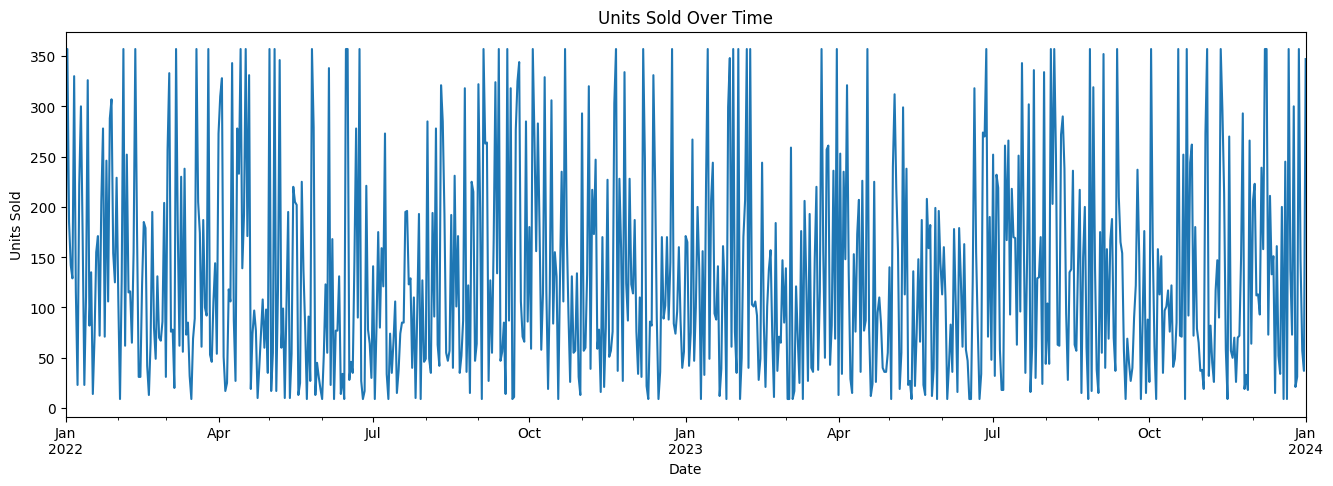

In [49]:
# Contoh untuk 1 kombinasi Store + Product (misalnya untuk modeling awal)
sample_ts = df_fe[(df_fe['Store ID'] == 'S002') & (df_fe['Product ID'] == 'P0010')]

# Set index tanggal & urutkan
sample_ts = sample_ts.sort_values('Date').set_index('Date')

# Lihat tren Units Sold
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 5))
sample_ts['Units Sold'].plot(title='Units Sold Over Time')
plt.ylabel('Units Sold')
plt.show()

### Modeling

📌 Opsi 1: Prophet (bagus untuk univariate forecasting per produk)
- ➕ Kelebihan:
Menangani seasonality, holiday, dan outlier otomatis.
Cocok untuk dataset retail.

In [51]:
from prophet import Prophet

In [52]:
# Siapkan data sesuai format Prophet
prophet_df = sample_ts.reset_index()[['Date', 'Units Sold']]
prophet_df.columns = ['ds', 'y']  # Prophet butuh nama ini

In [53]:
# Buat model dan fit
model = Prophet()
model.fit(prophet_df)

14:49:56 - cmdstanpy - INFO - Chain [1] start processing
14:49:56 - cmdstanpy - INFO - Chain [1] done processing


In [54]:
# Buat future data (misal 30 hari ke depan)
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

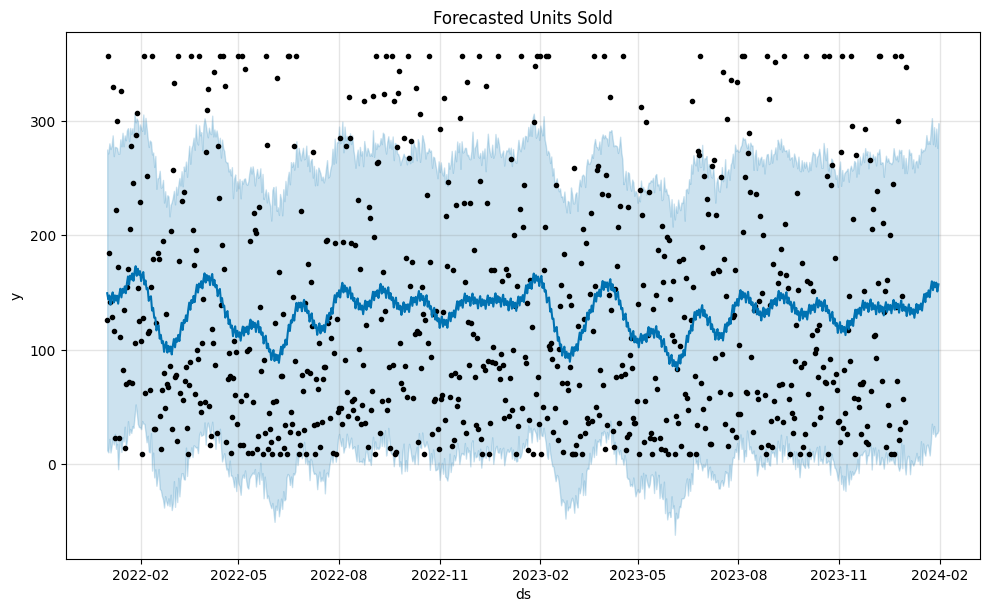

In [55]:
# Plot hasil prediksi
fig = model.plot(forecast)
plt.title('Forecasted Units Sold')
plt.show()

#### 📌 Machine Learning Approach (XGBoost, LightGBM, dll)

Ini lebih cocok untuk multi-store, multi-product forecasting, apalagi jika banyak faktor eksternal (weather, promo, dsb).

- 🧠 Langkah Umum:
1. Feature Engineering waktu (sudah kita lakukan)
2. Sort berdasarkan waktu
3. Lag features: fitur jumlah unit di hari-hari sebelumnya
4. Split train-test berdasarkan waktu
5. Train XGBoost atau model lain

In [57]:
df_ml = df_fe.copy()

In [58]:
# Urut berdasarkan tanggal
df_ml = df_ml.sort_values(['Store ID', 'Product ID', 'Date'])

In [59]:
for lag in [1, 7, 14]:
    df_ml[f'Lag_{lag}'] = df_ml.groupby(['Store ID', 'Product ID'])['Units Sold'].shift(lag)

In [60]:
# Hapus baris dengan nilai NaN akibat lag
df_ml = df_ml.dropna()

In [61]:
# Train-test split berdasarkan tanggal (misalnya, 80% train)
cutoff_date = df_ml['Date'].quantile(0.8)
train = df_ml[df_ml['Date'] <= cutoff_date]
test = df_ml[df_ml['Date'] > cutoff_date]

In [62]:
# Fitur dan target
features = ['Lag_1', 'Lag_7', 'Lag_14', 'Inventory Level', 'Price', 'Discount',
            'Competitor Pricing', 'Holiday/Promotion', 'IsWeekend', 'Stock Gap']

X_train = train[features]
y_train = train['Units Sold']
X_test = test[features]
y_test = test['Units Sold']

##### 🏋️ Train Model XGBoost:

In [63]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

In [64]:
model = XGBRegressor(n_estimators=100, learning_rate=0.1)
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

In [65]:
print(f"Mean Absolute Error: {mae:.2f}")

Mean Absolute Error: 66.67


### Evaluation Model

In [66]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [70]:
# Hitung metrik
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2 = r2_score(y_test, y_pred)

In [71]:
# Tampilkan hasil
print(f"📊 Evaluasi Model:")
print(f"MAE  (Mean Absolute Error)      : {mae:.2f}")
print(f"RMSE (Root Mean Squared Error)  : {rmse:.2f}")
print(f"MAPE (Mean Absolute Percentage Error): {mape:.2f}%")
print(f"R² (R-squared)                  : {r2:.3f}")

📊 Evaluasi Model:
MAE  (Mean Absolute Error)      : 66.67
RMSE (Root Mean Squared Error)  : 83.71
MAPE (Mean Absolute Percentage Error): 146.07%
R² (R-squared)                  : 0.336


**📌 Tips Interpretasi:**
- MAE dan RMSE: Semakin kecil, semakin baik.
- MAPE < 10% = sangat baik, 10–20% = baik, >20% perlu peningkatan.
- R² mendekati 1 = prediksi sangat baik, di bawah 0.5 = kurang baik.

### 📈Visualization

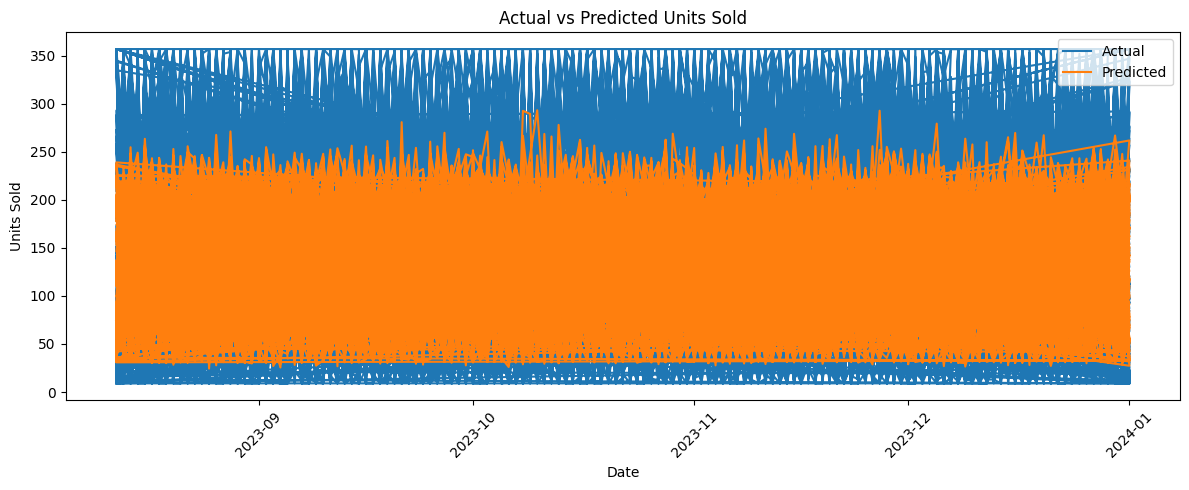

In [72]:
plt.figure(figsize=(12, 5))
plt.plot(test['Date'], y_test.values, label='Actual')
plt.plot(test['Date'], y_pred, label='Predicted')
plt.title('Actual vs Predicted Units Sold')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

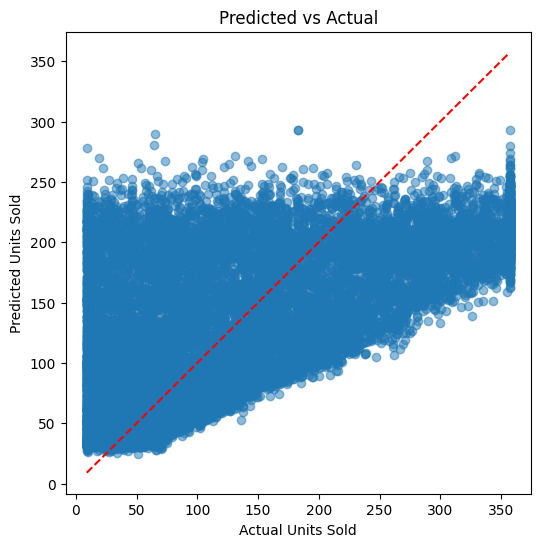

In [73]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Units Sold')
plt.ylabel('Predicted Units Sold')
plt.title('Predicted vs Actual')
plt.show()

In [74]:
df_ml.head(3)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,DayOfWeek,Month,IsWeekend,Stock Gap,Price After Discount,Demand Accuracy,IsHighCompetition,Lag_1,Lag_7,Lag_14
1400,2022-01-15,S001,P0001,Groceries,North,290,176,94,170.06,95.51,10,Rainy,1,95.69,Spring,5,1,1,196,85.51,5.94,0,177.0,9.0,127.0
1500,2022-01-16,S001,P0001,Groceries,East,104,97,189,114.65,14.33,15,Snowy,0,14.37,Winter,6,1,1,-85,-0.67,17.65,0,176.0,350.0,81.0
1600,2022-01-17,S001,P0001,Groceries,East,134,69,95,73.59,95.27,0,Rainy,1,92.60,Summer,0,1,0,39,95.27,4.59,1,97.0,36.0,9.0
